# Two-Electron 2D Schrödinger Solver — DVR / CI / RL


| Section | Content |
|:--------|:--------|
| 0 | Imports and physical parameters |
| 1 | Discrete Variable Representation (DVR) |
| 2 | Double-well potential |
| 3 | Single-particle eigenstates |
| 4 | Slater-determinant basis (energy-sorted — bug fix) |
| 5 | Coulomb kernel |
| 6 | CI Hamiltonian and two-electron spectrum |
| 7 | Spin, entanglement and orbital localisation |
| 8 | Model-aware RL (Belliardo et al. 2024) |

> **Bug fixed in this version:** the original code used an index-ordered Slater basis
> truncated at `n_compute = 40`, silently excluding all `(L_excited, R)` configurations
> such as `(L1, R0)`, `(L2, R0)` even though their one-body energy matches included
> `(L0, R_excited)` states.  The fix — `build_slater_basis_sorted` +
> `N_CI_COMPUTE = 200` — is demonstrated in Section 4.


---
## Section 0 — Imports and Physical Parameters

In [1]:
%matplotlib inline
import numpy as np
from scipy.linalg import eigh
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Physical / grid parameters (same as main())
Nx, Ny   = 20, 20
x0, xL   = -1.0,  1.0
y0, yL   = -0.5,  0.5
params   = {'a': 0.6, 'k': 1000.0, 'ky': 1500.0, 'delta': 0, 'd': 1.0}
kappa    = 2326.0    # Coulomb strength (Mott-Hubbard crossover, U/t ~ 1)
epsilon  = 0.01       # Coulomb softening length
Nstates  = 40  
M_LOC     = 12     # localisation subspace size (try 8, 12, 16, ...)
X_CUT     = 0.0    # dividing surface between wells (barrier centre)
SMOOTH_PL = True
SIGMA_PL  = 0.03      # SP orbitals to retain

print(f"Grid     : {Nx}x{Ny} = {Nx*Ny} points  [{x0},{xL}] x [{y0},{yL}]")
print(f"kappa    : {kappa}")
print(f"epsilon  : {epsilon}")
print(f"Nstates  : {Nstates}")


Grid     : 20x20 = 400 points  [-1.0,1.0] x [-0.5,0.5]
kappa    : 2326.0
epsilon  : 0.01
Nstates  : 40


---
## Section 1 — Discrete Variable Representation (DVR)

The sine-DVR maps $[x_0, x_L]$ onto $N$ grid points and returns the exact
kinetic-energy matrix in the DVR basis.  The 2-D kinetic matrix is a
Kronecker sum:

$$T_{2D} = T_x \otimes I_y + I_x \otimes T_y$$


In [2]:
def sine_dvr_1d(x0, xL, N):
    """1-D sine-DVR on [x0, xL] with N grid points.  hbar^2/2m = 1."""
    L = xL - x0
    x = x0 + np.arange(1, N + 1) * L / (N + 1)
    w = np.full(N, L / (N + 1))
    j = np.arange(1, N + 1)
    U = np.sqrt(2 / (N + 1)) * np.sin(np.outer(j, j * np.pi / (N + 1)))
    T = (U.T * (j * np.pi / L) ** 2) @ U
    return x, w, T


def build_2d_dvr(Nx=20, Ny=20, x0=-1.0, xL=1.0, y0=-0.5, yL=0.5):
    xg, wx, Tx = sine_dvr_1d(x0, xL, Nx)
    yg, wy, Ty = sine_dvr_1d(y0, yL, Ny)
    T2D = np.kron(Tx, np.eye(Ny)) + np.kron(np.eye(Nx), Ty)
    return xg, yg, wx, wy, T2D


x_grid, y_grid, w_x, w_y, T2D = build_2d_dvr(Nx, Ny, x0, xL, y0, yL)
print(f"DVR grid : {Nx}x{Ny} = {Nx*Ny} points")
print(f"T2D shape: {T2D.shape}")


DVR grid : 20x20 = 400 points
T2D shape: (400, 400)


---
## Section 2 — Double-Well Potential

$$V(x,y) = k\left[\left(\frac{x}{d}\right)^2 - a^2\right]^2
           + \delta\,x + \tfrac{1}{2}k_y\,y^2$$

Wells sit at $x = \pm a\,d$.  The linear tilt $\delta$ introduces asymmetry.


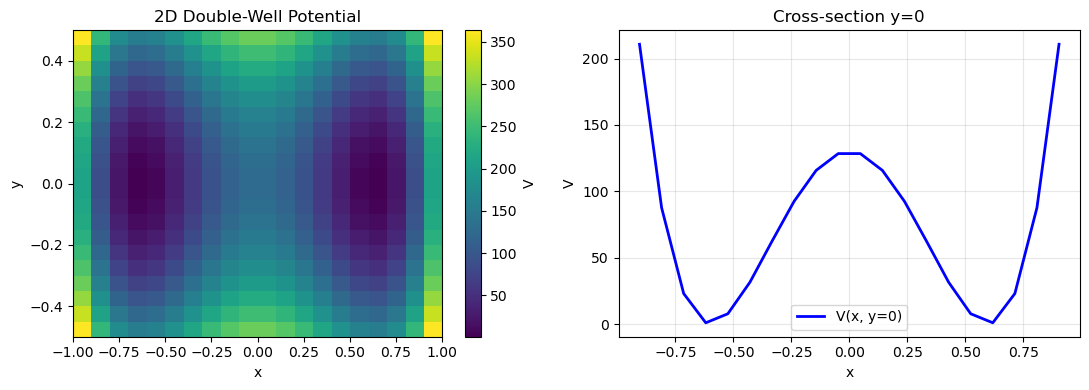

Well minima at x = +/-0.600


In [3]:
def double_well_potential(x, y, params):
    a     = params.get('a',     1.0)
    k     = params.get('k',    50.0)
    ky    = params.get('ky',  100.0)
    delta = params.get('delta', 0.5)
    d     = params.get('d',     1.0)
    return k * ((x / d)**2 - a**2)**2 + delta * x + 0.5 * ky * y**2


def build_potential_matrix(x_grid, y_grid, params):
    X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
    V    = double_well_potential(X, Y, params).ravel()
    return np.diag(V)


V2D = build_potential_matrix(x_grid, y_grid, params)

X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
V2d  = double_well_potential(X, Y, params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
im = ax1.imshow(V2d.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='viridis')
plt.colorbar(im, ax=ax1, label='V')
ax1.set(title='2D Double-Well Potential', xlabel='x', ylabel='y')
ax2.plot(x_grid, V2d[:, Ny // 2], 'b-', lw=2, label='V(x, y=0)')
ax2.set(title='Cross-section y=0', xlabel='x', ylabel='V')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_potential.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Well minima at x = +/-{params['a'] * params['d']:.3f}")


---
## Section 3 — Single-Particle Eigenstates

Diagonalise $H_{sp} = T_{2D} + V_{2D}$ for the single-electron spectrum
$\varepsilon_k$, $\psi_k$.


In [4]:
def single_particle_eigenstates(T2D, V2D, Nstates=40):
    e_vals, e_vecs = eigh(T2D + V2D)
    return e_vals[:Nstates], e_vecs[:, :Nstates]


print("Diagonalising single-particle Hamiltonian...")
single_energies, single_vecs = single_particle_eigenstates(T2D, V2D, Nstates)

print("\nLowest 10 single-particle energies:")
for i, e in enumerate(single_energies[:10]):
    print(f"  psi_{i:2d}  E = {e:10.4f}")


Diagonalising single-particle Hamiltonian...

Lowest 10 single-particle energies:
  psi_ 0  E =    63.9667
  psi_ 1  E =    64.0289
  psi_ 2  E =   120.3798
  psi_ 3  E =   120.4420
  psi_ 4  E =   127.3519
  psi_ 5  E =   130.8141
  psi_ 6  E =   170.5505
  psi_ 7  E =   182.3630
  psi_ 8  E =   182.4252
  psi_ 9  E =   183.7650


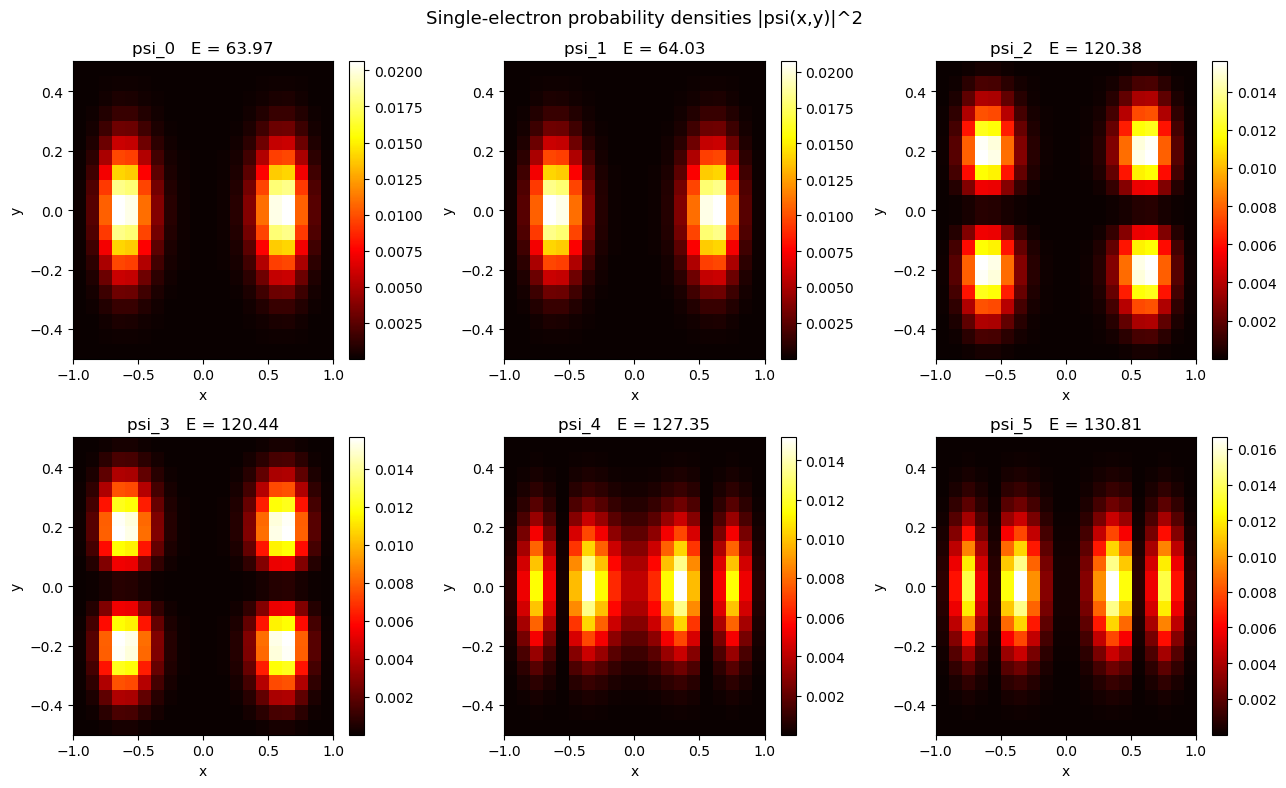

In [5]:
# Plot |psi|^2 for lowest 6 states
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, ax in enumerate(axes.flatten()):
    Z  = single_vecs[:, i].reshape(Nx, Ny)**2
    im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='hot')
    ax.set(title=f'psi_{i}   E = {single_energies[i]:.2f}', xlabel='x', ylabel='y')
    plt.colorbar(im, ax=ax)
plt.suptitle("Single-electron probability densities |psi(x,y)|^2", fontsize=13)
plt.tight_layout()
plt.savefig('nb_sp_states.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 3b — Localised Single-Particle Basis (Left/Right) via Projectors (FPM)

The single-particle eigenstates $\psi_k$ of $H_sp$ are typically delocalised across
the two wells.  For site (well) entanglement and Hubbard-like modelling it is
useful to rotate the lowest M eigenstates into an orthonormal set of
left- and right-localised orbitals.

We implement the robust "projector method":
 1) choose a low-energy subspace spanned by {$\psi_k$}_{k=0..M-1}
 2) define a left projector $P_L(x,y)$ (hard or smooth cut at x = x_cut)
 3) form $P_{ij} = \braket{\psi_i | P_L | \psi_j}$ in that subspace
 4) diagonalise P: eigenvalues near 1 -> left-localised, near 0 -> right-localised

This yields localised orbitals $\phi_\mu(x,y) = \sum_k U_{loc}[k,\mu] \psi_k(x,y)$
within the chosen subspace.

In [6]:
def build_left_projector_mask(x_grid, y_grid, x_cut=0.0, smooth=False, sigma=0.02):
    """
    Return P_L(x,y) on the DVR grid as a flattened array in [0,1].

    If smooth=False: hard step at x_cut.
    If smooth=True : smooth Fermi-type step of width sigma.
    """
    X, _ = np.meshgrid(x_grid, y_grid, indexing='ij')
    if not smooth:
        PL = (X < x_cut).astype(float)
    else:
        PL = 1.0 / (1.0 + np.exp((X - x_cut) / sigma))
    return PL.ravel()

def localise_orbitals_projector_DVR(single_vecs, x_grid, y_grid,
                                    M=16, x_cut=0.0, smooth=True, sigma=0.03):
    PLg = build_left_projector_mask(x_grid, y_grid, x_cut=x_cut,
                                    smooth=smooth, sigma=sigma)   # (G,)
    V = single_vecs[:, :M]                                        # (G,M)

    # Psub_ij = <psi_i | PL | psi_j> in the DVR inner product
    Psub = V.T @ (PLg[:, None] * V)

    lam, U = eigh(Psub)
    idx = np.argsort(lam)[::-1]
    lam, U = lam[idx], U[:, idx]

    vecs_loc = V @ U
    labels = np.array(['L' if l > 0.5 else 'R' for l in lam], dtype=object)

    # sanity: orthonormality in DVR inner product
    S = vecs_loc.T @ vecs_loc
    return U, vecs_loc, lam, labels, S


In [7]:
M_LOC=32
U_loc, vecs_loc, lam_loc, lr_labels, S_ortho = localise_orbitals_projector_DVR(
    single_vecs, x_grid, y_grid,
    M=M_LOC, x_cut=X_CUT, smooth=SMOOTH_PL, sigma=SIGMA_PL
)

print("lam range:", lam_loc.min(), lam_loc.max())
print("||S-I||_max =", np.max(np.abs(S_ortho - np.eye(M_LOC))))

lam range: 1.1012362513192346e-08 0.999999988987639
||S-I||_max = 1.5143442055887135e-13


In [8]:
def plot_localised_orbitals(vecs_loc, Nx, Ny,
                            x0, xL, y0, yL,
                            lam=None, labels=None,
                            idx_list=None, n_show=6,
                            cmap='hot', savepath=None):

    M = vecs_loc.shape[1]

    if idx_list is None:
        idx_list = list(range(min(n_show, M)))
    else:
        idx_list = list(idx_list)

    n_show = len(idx_list)
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 8))
    axes = axes.ravel()

    for j, ax in enumerate(axes):
        if j >= n_show:
            ax.axis('off')
            continue

        mu = idx_list[j]
        Z = (vecs_loc[:, mu].reshape(Nx, Ny))**2
        im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL),
                       aspect='auto', cmap=cmap)

        title = f'phi_{mu}'
        if lam is not None:
            title += f'  lam={float(lam[mu]):.3f}'
        if labels is not None:
            title += f'  ({labels[mu]})'
        ax.set_title(title)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()
    return 

32


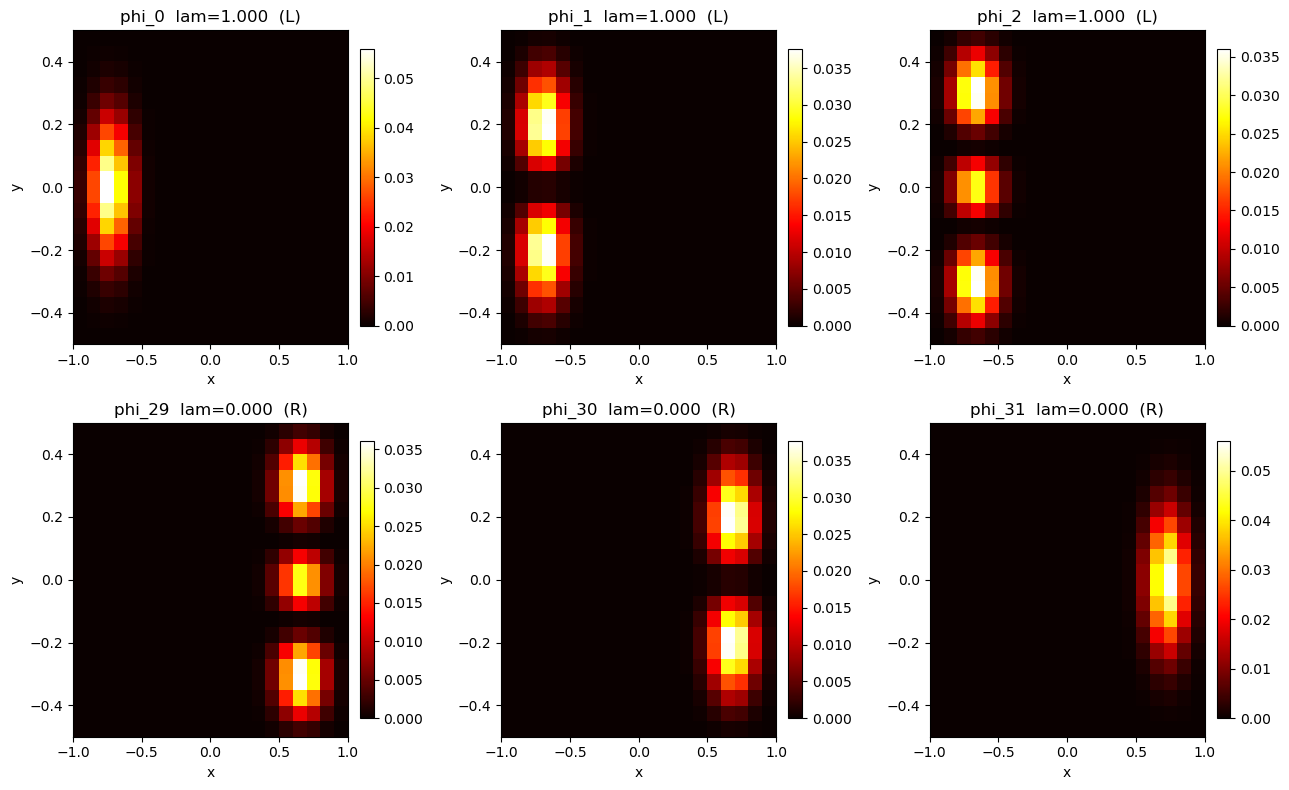

In [9]:
# Localised orbitals: show 3 most L and 3 most R (by lam value)
M = vecs_loc.shape[1]
print(M)
idx = list(range(0,3)) + list(range(M-3, M))
plot_localised_orbitals(vecs_loc, Nx, Ny, x0, xL, y0, yL,
                        lam=lam_loc, labels=lr_labels,
                        idx_list=idx)

---
## Section 4 — Slater-Determinant Basis (energy-sorted — bug fix)

### The original bug

`build_slater_basis()` ordered pairs as `(0,0),(0,1),...,(0,Nb-1),(1,1),(1,2),...`
so truncating to `n_compute = 40` kept only pairs involving orbital 0.
In the double-well this meant every `(L_excited, R)` configuration —
`(L1,R0)`, `(L2,R0)`, … — was absent from the CI despite having the same
one-body energy as the included `(L0, R_excited)` states.

| Basis index (old) | Config | $E_a+E_b$ | In n=40? |
|:---:|:---:|:---:|:---:|
| 1 | (L0, R0) | 128 | YES |
| 37 | (L0, R4) | 249 | YES (last) |
| **158** | **(L1, R0)** | **184** | **NO — cut off** |
| **166** | **(L2, R0)** | **193** | **NO — cut off** |

### The fix

`build_slater_basis_sorted()` sorts by $E_a+E_b$ so all configurations
in the energy window enter the CI regardless of orbital index.
`N_CI_COMPUTE = 200` covers L0–L4 × R0–R4 comfortably.


In [10]:
def build_slater_basis(Nb):
    """Original index-ordered basis (kept for reference/backward compatibility)."""
    basis = []
    for a in range(Nb):
        for b in range(a, Nb):
            if a == b:
                basis.append((a, b, 'ud', 'singlet'))
            else:
                basis.append((a, b, 'singlet',   'singlet'))
                basis.append((a, b, 'uu',         'triplet_p'))
                basis.append((a, b, 'triplet_0',  'triplet_0'))
                basis.append((a, b, 'dd',         'triplet_m'))
    return basis


def build_slater_basis_sorted(Nb, single_energies):
    """
    Energy-sorted Slater basis.

    Sorts all (a,b) orbital pairs by E_a + E_b before returning, so that
    truncating to n_compute determinants captures all configurations in
    the lowest energy window -- including L-excited (1,1) states such as
    (L1,R0) that the index-ordered basis placed at index >= 158.
    """
    raw = []
    for a in range(Nb):
        for b in range(a, Nb):
            Eab = float(single_energies[a]) + float(single_energies[b])
            if a == b:
                raw.append((Eab, a, b, 'ud',        'singlet'))
            else:
                raw.append((Eab, a, b, 'singlet',   'singlet'))
                raw.append((Eab, a, b, 'uu',        'triplet_p'))
                raw.append((Eab, a, b, 'triplet_0', 'triplet_0'))
                raw.append((Eab, a, b, 'dd',        'triplet_m'))
    raw.sort(key=lambda x: (x[0], x[1], x[2]))
    return [(a, b, sc, st) for (_, a, b, sc, st) in raw]


N_CI_COMPUTE  = 200   # raised from 40; covers L0-L4 x R0-R4

old_basis    = build_slater_basis(Nstates)
sorted_basis = build_slater_basis_sorted(Nstates, single_energies)

print(f"Full basis size              : {len(old_basis)}")
print(f"n_compute used               : {N_CI_COMPUTE}")
print()
print("First 10 entries of energy-sorted basis:")
for i, (a, b, sc, st) in enumerate(sorted_basis[:10]):
    Eab = single_energies[a] + single_energies[b]
    print(f"  [{i:3d}]  ({a:2d},{b:2d})  {st:<12}  E_a+E_b = {Eab:.2f}")


Full basis size              : 3160
n_compute used               : 200

First 10 entries of energy-sorted basis:
  [  0]  ( 0, 0)  singlet       E_a+E_b = 127.93
  [  1]  ( 0, 1)  singlet       E_a+E_b = 128.00
  [  2]  ( 0, 1)  triplet_p     E_a+E_b = 128.00
  [  3]  ( 0, 1)  triplet_0     E_a+E_b = 128.00
  [  4]  ( 0, 1)  triplet_m     E_a+E_b = 128.00
  [  5]  ( 1, 1)  singlet       E_a+E_b = 128.06
  [  6]  ( 0, 2)  singlet       E_a+E_b = 184.35
  [  7]  ( 0, 2)  triplet_p     E_a+E_b = 184.35
  [  8]  ( 0, 2)  triplet_0     E_a+E_b = 184.35
  [  9]  ( 0, 2)  triplet_m     E_a+E_b = 184.35


In [11]:
# Orbital localisation helper (needed to show L-rank in demo below)
def orbital_localization(single_vecs, single_energies, x_grid, y_grid,
                          Nstates=40, loc_threshold=0.20):
    Nx, Ny = len(x_grid), len(y_grid)
    X2d, _ = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf     = X2d.ravel()
    prob   = single_vecs[:, :Nstates]**2
    ex_all = Xf @ prob
    info   = []
    for idx in range(Nstates):
        ex = float(ex_all[idx])
        if   ex < -loc_threshold: label, wc = "Left well",   'L'
        elif ex >  loc_threshold: label, wc = "Right well",  'R'
        else:                     label, wc = "Delocalized", 'D'
        info.append((idx, float(single_energies[idx]), ex, label, wc))
    return info


orbital_info = orbital_localization(single_vecs, single_energies,
                                     x_grid, y_grid, Nstates)
well   = {o[0]: o[4] for o in orbital_info}
L_orbs = sorted([o[0] for o in orbital_info if o[4]=='L'], key=lambda i: single_energies[i])
R_orbs = sorted([o[0] for o in orbital_info if o[4]=='R'], key=lambda i: single_energies[i])
rank_L = {orb: k for k, orb in enumerate(L_orbs)}
rank_R = {orb: k for k, orb in enumerate(R_orbs)}

print(f"L orbitals: {[f'L{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(L_orbs[:5])]}")
print(f"R orbitals: {[f'R{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(R_orbs[:5])]}")
print()

# Compare how the first (1,1) singlets appear in each ordering
print("First (1,1) singlets in each basis ordering:")
print(f"  {'Basis':>12}  {'Index':>6}  {'Config':>10}  {'E_a+E_b':>10}  In n=40?")
print("  " + "-"*52)
for bname, basis in [("index-ord.", old_basis), ("energy-sort", sorted_basis)]:
    shown = 0
    for idx, (a, b, sc, st) in enumerate(basis):
        if st != 'singlet': continue
        wa = well.get(a, 'D'); wb = well.get(b, 'D')
        if not ((wa=='L' and wb=='R') or (wa=='R' and wb=='L')): continue
        la = rank_L.get(a if wa=='L' else b, -1)
        Eab = single_energies[a] + single_energies[b]
        flag = "YES" if idx < 40 else "NO"
        print(f"  {bname:>12}  {idx:>6}  L{la}-R?  {Eab:>10.2f}  {flag}")
        shown += 1
        if shown >= 5: break


L orbitals: []
R orbitals: []

First (1,1) singlets in each basis ordering:
         Basis   Index      Config     E_a+E_b  In n=40?
  ----------------------------------------------------


---
## Section 5 — Coulomb Kernel

$$K[g_1, g_2] = \frac{w_{g_1}\,w_{g_2}\,\kappa}
                      {\sqrt{|\mathbf{r}_1-\mathbf{r}_2|^2+\varepsilon^2}}$$

Precomputed once as a $(G\times G)$ matrix.  All two-electron integrals
$(ac|bd)$ are then matrix-vector products against $K$.


In [12]:
def precompute_coulomb_kernel(x_grid, y_grid, wx, wy, kappa=1.0, epsilon=0.1):
    X, Y    = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf, Yf  = X.ravel(), Y.ravel()
    Wx, Wy  = np.meshgrid(wx, wy, indexing='ij')
    Wf      = (Wx * Wy).ravel()
    dx = Xf[:, None] - Xf[None, :]
    dy = Yf[:, None] - Yf[None, :]
    r12 = np.sqrt(dx**2 + dy**2 + epsilon**2)
    return kappa / r12 * Wf[:, None] * Wf[None, :]


print(f"Building Coulomb kernel (kappa={kappa}, epsilon={epsilon})...")
K = precompute_coulomb_kernel(x_grid, y_grid, w_x, w_y, kappa, epsilon)
print(f"K shape : {K.shape}  ({K.nbytes / 1e6:.1f} MB)")
print(f"K range : [{K.min():.3e}, {K.max():.3e}]")


Building Coulomb kernel (kappa=2326.0, epsilon=0.01)...
K shape : (400, 400)  (1.3 MB)
K range : [2.365e-02, 4.784e+00]


---
## Section 6 — CI Hamiltonian and Two-Electron Spectrum

Slater–Condon matrix element rules (Szabo & Ostlund §2.3):

| Element | Formula |
|:--------|:--------|
| $\langle aa\,S \| V \| aa\,S \rangle$ | $J(a,a)$ |
| $\langle ab\,S \| V \| ab\,S \rangle$ | $J(a,b)+K(a,b)$ |
| $\langle ab\,T \| V \| ab\,T \rangle$ | $J(a,b)-K(a,b)$ |
| $\langle aa\,S \| V \| bb\,S \rangle$ | $K_{ex}(a,b)$ |
| $\langle aa\,S \| V \| cd\,S \rangle$ | $\frac{1}{\sqrt{2}}(ac|ad)$ |
| $\langle ab\,S \| V \| cd\,S \rangle$ | $(ac|bd)+(ad|bc)$ |
| $\langle ab\,T \| V \| cd\,T \rangle$ | $(ac|bd)-(ad|bc)$ |


In [13]:
def build_ci_hamiltonian(slater_basis, single_energies, sv, K, n_compute=40):
    n  = min(n_compute, len(slater_basis))
    H  = np.zeros((n, n))
    _te_cache = {}
    def te(a, b, c, d):
        key = (a, b, c, d)
        if key not in _te_cache:
            _te_cache[key] = float((sv[:, a] * sv[:, c]) @ K @ (sv[:, b] * sv[:, d]))
        return _te_cache[key]

    for I in range(n):
        a_I, b_I, _, stype_I = slater_basis[I]
        same_I = (a_I == b_I)
        for J in range(I, n):
            a_J, b_J, _, stype_J = slater_basis[J]
            if stype_I != stype_J: continue
            same_J = (a_J == b_J); val = 0.0
            if I == J:
                val += single_energies[a_I] + single_energies[b_I]
            if stype_I == 'singlet':
                if same_I and same_J:
                    if a_I == a_J: val += te(a_I, a_I, a_I, a_I)
                    else:          val += 2.0 * te(a_I, a_J, a_I, a_J)
                elif same_I:  val += np.sqrt(2.0) * te(a_I, a_J, a_I, b_J)
                elif same_J:  val += np.sqrt(2.0) * te(a_I, a_J, b_I, a_J)
                else:         val += te(a_I, a_J, b_I, b_J) + te(a_I, b_J, b_I, a_J)
            else:
                if not same_I and not same_J:
                    val += te(a_I, a_J, b_I, b_J) - te(a_I, b_J, b_I, a_J)
            H[I, J] += val
            if I != J: H[J, I] = H[I, J]
    return H


print(f"Building {N_CI_COMPUTE}x{N_CI_COMPUTE} CI Hamiltonian (energy-sorted basis)...")
slater_basis = build_slater_basis_sorted(Nstates, single_energies)
n_compute    = min(N_CI_COMPUTE, len(slater_basis))
H_slater     = build_ci_hamiltonian(slater_basis, single_energies,
                                     single_vecs, K, n_compute)
E2, C2 = eigh(H_slater)
print(f"Done.  n_compute = {n_compute},  lowest E = {E2[0]:.4f}")


Building 200x200 CI Hamiltonian (energy-sorted basis)...
Done.  n_compute = 200,  lowest E = 127.7779


In [14]:
# Config label helper
def cfg_label(a, b):
    wa = well.get(a, 'D'); wb = well.get(b, 'D')
    def lbl(idx, w):
        if w == 'L': return f"L{rank_L[idx]}"
        if w == 'R': return f"R{rank_R[idx]}"
        return f"D{idx}"
    return f"{lbl(a,wa)}-{lbl(b,wb)}"

_SPIN = {'singlet':(0.,0.),'triplet_p':(2.,1.),'triplet_0':(2.,0.),'triplet_m':(2.,-1.)}

print("Two-electron spectrum (lowest 20 states):")
print(f"  {'#':>3}  {'Energy':>10}  {'dE':>8}  {'Spin':>8}  {'Config':>10}")
print("  " + "-"*46)
for i in range(min(20, len(E2))):
    dom  = int(np.argmax(np.abs(C2[:, i])))
    a_d, b_d = slater_basis[dom][0], slater_basis[dom][1]
    S2   = sum(C2[:,i]**2 * [_SPIN[slater_basis[j][3]][0] for j in range(n_compute)])
    spin = 'Singlet' if S2 < 0.5 else 'Triplet'
    cfg  = cfg_label(a_d, b_d)
    print(f"  {i:>3}  {E2[i]:>10.4f}  {E2[i]-E2[0]:>8.4f}  {spin:>8}  {cfg:>10}")


Two-electron spectrum (lowest 20 states):
    #      Energy        dE      Spin      Config
  ----------------------------------------------
    0    127.7779    0.0000   Singlet       D0-D0
    1    127.9956    0.2177   Triplet       D0-D1
    2    127.9956    0.2177   Triplet       D0-D1
    3    127.9956    0.2177   Triplet       D0-D1
    4    128.3346    0.5567   Singlet       D0-D1
    5    128.6327    0.8548   Singlet       D1-D1
    6    184.3465   56.5686   Triplet       D0-D2
    7    184.3465   56.5686   Triplet       D0-D2
    8    184.3465   56.5686   Triplet       D0-D2
    9    184.3928   56.6149   Singlet       D0-D2
   10    184.4087   56.6308   Triplet       D0-D3
   11    184.4087   56.6308   Triplet       D0-D3
   12    184.4087   56.6308   Triplet       D0-D3
   13    184.4087   56.6308   Singlet       D0-D3
   14    184.4087   56.6308   Triplet       D1-D2
   15    184.4087   56.6308   Triplet       D1-D2
   16    184.4087   56.6308   Triplet       D1-D2
   17    

---
## Section 7 — Spin, Entanglement and Orbital Localisation

For each two-electron CI eigenstate:
- $\langle S^2 \rangle$, $\langle S_z \rangle$ (spin character)
- Von Neumann entropy of the 1-RDM (entanglement)
- Well classification L/R/D from $\langle x \rangle$


In [15]:
# Orbital localisation printout
print("ORBITAL LOCALISATION")
print(f"  {'psi':>5} | {'Energy':>10} | {'<x>':>8} | Well")
print("  " + "-"*42)
for idx, en, ex, lbl, wc in orbital_info:
    print(f"  psi_{idx:2d} | {en:10.4f} | {ex:8.4f} | {lbl}")


ORBITAL LOCALISATION
    psi |     Energy |      <x> | Well
  ------------------------------------------
  psi_ 0 |    63.9667 |   0.0000 | Delocalized
  psi_ 1 |    64.0289 |  -0.0000 | Delocalized
  psi_ 2 |   120.3798 |   0.0000 | Delocalized
  psi_ 3 |   120.4420 |  -0.0000 | Delocalized
  psi_ 4 |   127.3519 |  -0.0000 | Delocalized
  psi_ 5 |   130.8141 |   0.0000 | Delocalized
  psi_ 6 |   170.5505 |  -0.0000 | Delocalized
  psi_ 7 |   182.3630 |   0.0000 | Delocalized
  psi_ 8 |   182.4252 |  -0.0000 | Delocalized
  psi_ 9 |   183.7650 |   0.0000 | Delocalized
  psi_10 |   187.2272 |  -0.0000 | Delocalized
  psi_11 |   194.5457 |   0.0000 | Delocalized
  psi_12 |   226.9635 |   0.0000 | Delocalized
  psi_13 |   230.5996 |   0.0000 | Delocalized
  psi_14 |   245.7482 |   0.0000 | Delocalized
  psi_15 |   249.2104 |  -0.0000 | Delocalized
  psi_16 |   250.9588 |  -0.0000 | Delocalized
  psi_17 |   255.9622 |   0.0000 | Delocalized
  psi_18 |   256.0243 |  -0.0000 | Delocalized
  

In [16]:
_SPIN_TABLE = {
    'singlet':   (0.0,  0.0),
    'triplet_p': (2.0,  1.0),
    'triplet_0': (2.0,  0.0),
    'triplet_m': (2.0, -1.0),
}

def compute_spin_and_entanglement(eigenstate_coeffs, slater_basis, Nb):
    """<S^2>, <Sz> and von Neumann entropy of the 1-RDM."""
    coeffs = np.asarray(eigenstate_coeffs)
    probs  = coeffs.real**2 + coeffs.imag**2
    S2 = Sz = 0.0
    for i, (_, _, _, st) in enumerate(slater_basis):
        s2, sz = _SPIN_TABLE.get(st, (0., 0.))
        S2 += probs[i] * s2; Sz += probs[i] * sz
    d   = 2 * Nb
    rho = np.zeros((d, d), dtype=complex)
    for i, c in enumerate(coeffs):
        if abs(c) < 1e-12: continue
        a, b, _, stype = slater_basis[i]
        ia_up, ia_dn = 2*a, 2*a+1
        ib_up, ib_dn = 2*b, 2*b+1
        if a == b:
            f = c / np.sqrt(2)
            rho[ia_up, ia_dn] += f; rho[ia_dn, ia_up] -= f
        elif stype == 'singlet':
            f = c / 2.
            rho[ia_up, ib_dn] += f; rho[ia_dn, ib_up] -= f
            rho[ib_up, ia_dn] += f; rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_p':
            f = c / np.sqrt(2)
            rho[ia_up, ib_up] += f; rho[ib_up, ia_up] -= f
        elif stype == 'triplet_0':
            f = c / 2.
            rho[ia_up, ib_dn] += f; rho[ia_dn, ib_up] += f
            rho[ib_up, ia_dn] -= f; rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_m':
            f = c / np.sqrt(2)
            rho[ia_dn, ib_dn] += f; rho[ib_dn, ia_dn] -= f
    rho1 = rho @ rho.conj().T
    eigv = np.linalg.eigvalsh(rho1)
    eigv = eigv[eigv > 1e-12]
    ent  = float(-np.dot(eigv, np.log(eigv))) if len(eigv) else 0.
    nrm  = np.trace(rho1).real
    return S2, Sz, ent


In [17]:
# Spin + entanglement table and spectrum plot
print("Spin and entanglement (first 40 states):")
print(f"  {'#':>4} | {'Energy':>10} | {'<S2>':>6} | {'<Sz>':>6} | {'Entropy':>8} | {'Config':>10} | Type")
print("  " + "="*72)
spin_S2_values, spin_Sz_values, entropies = [], [], []
for n in range(min(n_compute, len(E2))):
    S2, Sz, S_ent = compute_spin_and_entanglement(
        C2[:, n], slater_basis[:n_compute], Nstates)
    spin_S2_values.append(S2); spin_Sz_values.append(Sz); entropies.append(S_ent)
    dom = int(np.argmax(np.abs(C2[:, n])))
    cfg = cfg_label(slater_basis[dom][0], slater_basis[dom][1])
    lbl = ("Singlet"       if abs(S2) < 0.1 else
           "Triplet Ms=+1" if abs(Sz - 1.) < 0.1 else
           "Triplet Ms=0"  if abs(Sz) < 0.1 else
           "Triplet Ms=-1" if abs(Sz + 1.) < 0.1 else "Mixed")
    print(f"  {n:>4} | {E2[n]:>10.4f} | {S2:>6.2f} | {Sz:>6.2f} | "
          f"{S_ent:>8.4f} | {cfg:>10} | {lbl}")


Spin and entanglement (first 40 states):
     # |     Energy |   <S2> |   <Sz> |  Entropy |     Config | Type
     0 |   127.7779 |   0.00 |   0.00 |   1.3756 |      D0-D0 | Singlet
     1 |   127.9956 |   2.00 |  -0.11 |   1.3792 |      D0-D1 | Mixed
     2 |   127.9956 |   2.00 |  -0.20 |   1.0667 |      D0-D1 | Mixed
     3 |   127.9956 |   2.00 |   0.31 |   1.0728 |      D0-D1 | Mixed
     4 |   128.3346 |   0.00 |  -0.00 |   1.3864 |      D0-D1 | Singlet
     5 |   128.6327 |   0.00 |   0.00 |   1.3762 |      D1-D1 | Singlet
     6 |   184.3465 |   2.00 |  -0.10 |   1.2146 |      D0-D2 | Triplet Ms=0
     7 |   184.3465 |   2.00 |   0.97 |   0.7268 |      D0-D2 | Triplet Ms=+1
     8 |   184.3465 |   2.00 |  -0.87 |   0.8172 |      D0-D2 | Mixed
     9 |   184.3928 |   0.00 |  -0.00 |   1.9602 |      D0-D2 | Singlet
    10 |   184.4087 |   2.00 |  -0.18 |   1.6727 |      D0-D3 | Mixed
    11 |   184.4087 |   1.95 |  -0.74 |   1.3023 |      D0-D3 | Mixed
    12 |   184.4087 |   1.9

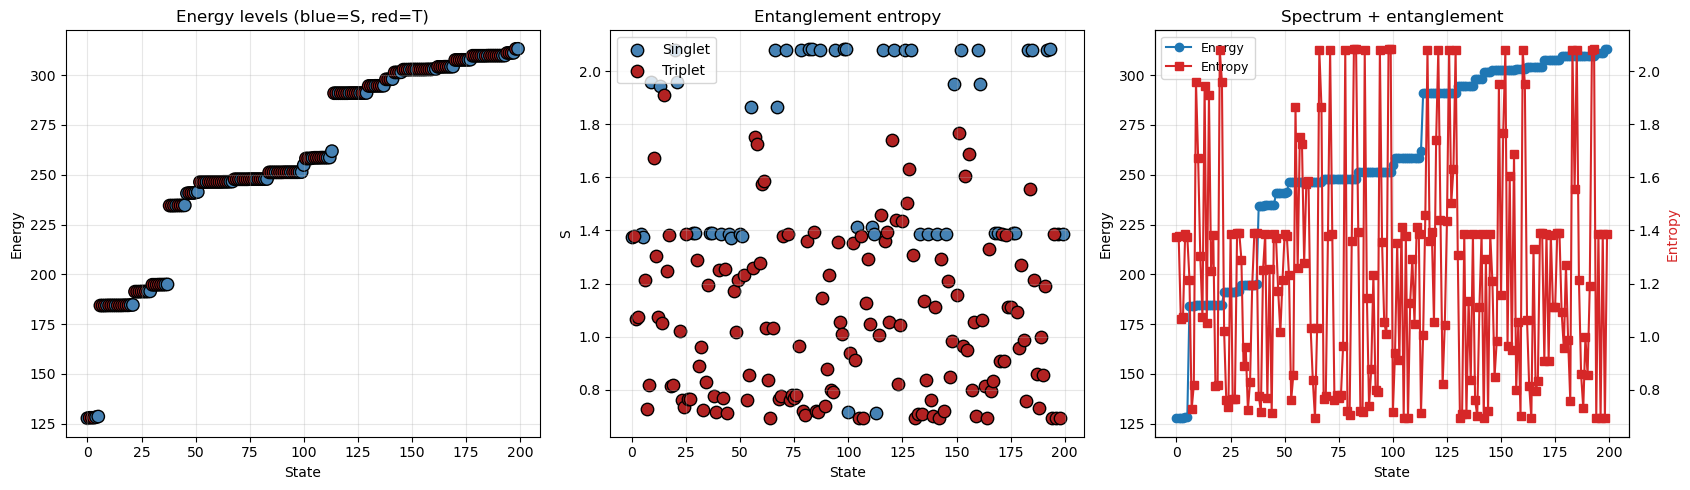

In [18]:
# Spectrum figure
n_plot  = min(len(E2), len(entropies))
idx_arr = np.arange(n_plot)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

colors = ['steelblue' if s < 0.5 else 'firebrick' for s in spin_S2_values[:n_plot]]
ax1.scatter(idx_arr, E2[:n_plot], c=colors, s=80, edgecolor='k', lw=1.0)
ax1.set(title='Energy levels (blue=S, red=T)', xlabel='State', ylabel='Energy')
ax1.grid(True, alpha=0.3)

sm = np.array(spin_S2_values[:n_plot]) < 0.5
if sm.any():
    ax2.scatter(idx_arr[sm],  np.array(entropies[:n_plot])[sm],
                c='steelblue', s=80, label='Singlet', edgecolor='k', lw=1.)
if (~sm).any():
    ax2.scatter(idx_arr[~sm], np.array(entropies[:n_plot])[~sm],
                c='firebrick', s=80, label='Triplet', edgecolor='k', lw=1.)
ax2.set(title='Entanglement entropy', xlabel='State', ylabel='S')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3b = ax3.twinx()
ax3.plot(idx_arr, E2[:n_plot], 'o-', color='tab:blue', lw=1.5, label='Energy')
ax3b.plot(idx_arr, entropies[:n_plot], 's-', color='tab:red', lw=1.5, label='Entropy')
ax3.set(xlabel='State', ylabel='Energy')
ax3b.set_ylabel('Entropy', color='tab:red')
ax3.set_title('Spectrum + entanglement')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_spectrum.png', dpi=120, bbox_inches='tight')
plt.show()


In [19]:
def analyze_spin_character(C_slater, slater_basis, verbose=True):
    """Fraction of singlet vs triplet weight per eigenstate."""
    n_states = C_slater.shape[1]; purities = []
    for n in range(n_states):
        probs  = C_slater[:, n]**2
        s_mask = np.array([s[3] == 'singlet' for s in slater_basis])
        sp = float(probs[s_mask].sum()); tp = float(probs[~s_mask].sum())
        tot = sp + tp
        pur = (sp - tp) / tot if tot > 1e-10 else 0.
        purities.append(pur)
        if verbose and n < 40:
            lbl = ("Pure Singlet"   if pur >  0.9 else
                   "Mostly Singlet" if pur >  0.5 else
                   "Pure Triplet"   if pur < -0.9 else
                   "Mostly Triplet" if pur < -0.5 else "Mixed")
            print(f"State {n:2d}: purity = {pur:+.3f}  ->  {lbl}  "
                  f"(S:{sp:.1%}  T:{tp:.1%})")
    return np.array(purities)

print("Spin purity analysis:")
purities = analyze_spin_character(C2, slater_basis[:n_compute], verbose=True)


Spin purity analysis:
State  0: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  1: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  2: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  3: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  4: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  5: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State  6: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  7: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  8: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State  9: purity = +1.000  ->  Pure Singlet  (S:100.0%  T:0.0%)
State 10: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State 11: purity = -0.951  ->  Pure Triplet  (S:2.4%  T:97.6%)
State 12: purity = -0.907  ->  Pure Triplet  (S:4.7%  T:95.3%)
State 13: purity = +0.848  ->  Mostly Singlet  (S:92.4%  T:7.6%)
State 14: purity = -1.000  ->  Pure Triplet  (S:0.0%  T:100.0%)
State 15: purity = 

 ---
## Section 7b — Left-well reduced density matrix in the localised L/R basis (with spin) FPM
 Here we compute the *site (mode)* reduced density matrix for the left well,
 using the *localised* single-particle basis from Section 3b, **including spin**.

 Steps for each CI eigenstate:
 1) Convert the CI eigenvector (spin-adapted Slater basis) into a 2-fermion
    amplitude matrix $Ω$ in the spin-orbital basis (size $d = 2*N_{states}$).
    (This is the same object your `compute_spin_and_entanglement` builds as `rho`.)
 2) Rotate spatial orbitals from the delocalised basis to the localised basis via $U_{loc}$,
    extended to spin-orbitals as $U_{spin} = I_2 ⊗ U_{loc}$.
    Then $Ω' = U_{spin} Ω U_{spin}^T$.
 3) Form the 2-fermion density matrix $ρ_2 = \ket{Ψ}\bra{Ψ}$ in the antisymmetrised pair basis.
    We do this implicitly by mapping Ω' -> pair amplitudes.
 4) Perform the mode partial trace over all **right-well spin-orbitals** to obtain $ρ_L$
    on the left-well Fock space sectors $N_L=0,1,2$.
 5) Compute S(ρ_L) and SSR-accessible entanglement $E_{acc}$.

$E_{acc}$ is the *accessible entanglement under a local particle‑number superselection rule (SSR)*.

When you bipartition by sites (left vs right), the left reduced state $ρ_L$ generally contains a mixture of different *local particle-number sectors* N_L = 0, 1, 2. Because local operations on the left cannot create or use coherence between different N_L sectors (they must conserve local particle number), not all of the von Neumann entropy $S(ρ_L)$ is operationally usable as entanglement.

So you decompose ρ_L into blocks:
- $ρ_L = ρ_L^{(0)} ⊕ ρ_L^{(1)} ⊕ ρ_L^{(2)}$
with probabilities
- $p_n = Tr(ρ_L^{(n)})$.

Then the *SSR-accessible entanglement* is
- $E_{acc} = Σ_n p_n S( ρ_L^{(n)} / p_n )$.

Interpretation:
- It *ignores “entanglement” coming purely from charge fluctuations* (uncertainty in whether the left site has 0,1,2 electrons).
- It keeps only the entanglement *within each fixed $N_L$ sector*, which is what you can access with SSR-respecting local operations.

In the code, that’s why $E_{acc}$ is computed by normalizing each block (divide by $p_n$), taking its entropy, and weighting by $p_n$.

 This avoids constructing the full $2^{(2*M_LOC)}$ Fock density matrix.

In [20]:
# --- (A) Build the 2-fermion antisymmetric amplitude matrix Ω in spin-orbital basis ---

def ci_to_spinorbital_Omega(coeffs, slater_basis, Nb):
    """
    Build antisymmetric 2-fermion amplitude matrix Ω_{pq} (p,q are spin-orbital indices)
    from CI coefficients in the spin-adapted slater_basis.

    This matches the structure used in compute_spin_and_entanglement(), but returns Ω.
    Conventions:
      spin-orbital index: p = 2*a (up), 2*a+1 (down)
      state |Ψ> = sum_{p<q} Ω_{pq} c_p^† c_q^† |0>
      Ω is antisymmetric: Ω_{pq} = -Ω_{qp}
    """
    coeffs = np.asarray(coeffs, dtype=complex)
    d = 2 * Nb
    Om = np.zeros((d, d), dtype=complex)

    for i, c in enumerate(coeffs):
        if abs(c) < 1e-14:
            continue
        a, b, _, stype = slater_basis[i]
        ia_up, ia_dn = 2*a, 2*a + 1
        ib_up, ib_dn = 2*b, 2*b + 1

        if a == b:
            # double occupancy (must be singlet): (|a↑ a↓> - |a↓ a↑>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_up, ia_dn] += f
            Om[ia_dn, ia_up] -= f

        elif stype == 'singlet':
            # (|a↑ b↓> - |a↓ b↑> + |b↑ a↓> - |b↓ a↑>)/2
            f = c / 2.0
            Om[ia_up, ib_dn] += f
            Om[ia_dn, ib_up] -= f
            Om[ib_up, ia_dn] += f
            Om[ib_dn, ia_up] -= f

        elif stype == 'triplet_p':
            # (|a↑ b↑> - |b↑ a↑>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_up, ib_up] += f
            Om[ib_up, ia_up] -= f

        elif stype == 'triplet_0':
            # (|a↑ b↓> + |a↓ b↑> - |b↑ a↓> - |b↓ a↑>)/2
            f = c / 2.0
            Om[ia_up, ib_dn] += f
            Om[ia_dn, ib_up] += f
            Om[ib_up, ia_dn] -= f
            Om[ib_dn, ia_up] -= f

        elif stype == 'triplet_m':
            # (|a↓ b↓> - |b↓ a↓>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_dn, ib_dn] += f
            Om[ib_dn, ia_dn] -= f

    return Om

In [21]:
def spinorbital_U_from_spatial(U_spatial):
    """
    Given U_spatial of shape (M, M) mapping spatial orbitals,
    build U_spin of shape (2M, 2M) acting on spin-orbitals ordered as:
      (0↑,0↓, 1↑,1↓, ..., (M-1)↑,(M-1)↓)
    """
    M = U_spatial.shape[0]
    U_spin = np.zeros((2*M, 2*M), dtype=complex)
    for a in range(M):
        for mu in range(M):
            U_spin[2*a,   2*mu]   = U_spatial[a, mu]  # up->up
            U_spin[2*a+1, 2*mu+1] = U_spatial[a, mu]  # dn->dn
    return U_spin

In [22]:
# --- (C) Pair-basis indexing for 2 fermions in d spin-orbitals (p<q) ---

def pair_basis(d):
    pairs = []
    idx = {}
    k = 0
    for p in range(d):
        for q in range(p+1, d):
            pairs.append((p, q))
            idx[(p, q)] = k
            k += 1
    return pairs, idx

In [23]:
def Omega_to_rho2_pair(Om, tol=1e-14):
    """
    Om: antisymmetric amplitude matrix Ω in spin-orbital basis (d x d)
    Returns: rho2 in antisymmetrised pair basis |pq> (p<q), size n2 x n2, trace=1
    """
    d = Om.shape[0]
    pairs, pidx = pair_basis(d)
    amp = np.zeros(len(pairs), dtype=complex)

    for k, (p, q) in enumerate(pairs):
        amp[k] = Om[p, q]

    # normalise the state (just in case)
    nrm = np.vdot(amp, amp).real
    if nrm < tol:
        raise ValueError("State norm ~0 in pair basis; check Ω construction.")
    amp = amp / np.sqrt(nrm)

    rho2 = np.outer(amp, amp.conj())
    return rho2, pairs

In [24]:
# --- (E) Partial trace over right-well spin-orbitals to get ρ_L in NL=0,1,2 blocks ---

def rhoL_from_rho2_pairs_spin(rho2, pairs, mode_tags_spin):
    """
    mode_tags_spin: list length d with 'L' or 'R' for each spin-orbital index.
    rho2: 2-fermion density matrix in pair basis (pairs list gives ordering).

    Returns: rhoL0 (scalar), rhoL1 (nLso x nLso), rhoL2 (nLLpairs x nLLpairs), plus meta.
    """
    d = len(mode_tags_spin)
    pair_index = {p: i for i, p in enumerate(pairs)}

    L_modes = [m for m,t in enumerate(mode_tags_spin) if t == 'L']
    R_modes = [m for m,t in enumerate(mode_tags_spin) if t == 'R']
    nLso = len(L_modes)
    Lpos = {m:i for i,m in enumerate(L_modes)}

    # classify pairs
    LL_pairs = [(p,q) for (p,q) in pairs if mode_tags_spin[p]=='L' and mode_tags_spin[q]=='L']
    RR_pairs = [(p,q) for (p,q) in pairs if mode_tags_spin[p]=='R' and mode_tags_spin[q]=='R']

    # NL=2 block
    nLL = len(LL_pairs)
    rhoL2 = np.zeros((nLL, nLL), dtype=complex)
    for i,(p,q) in enumerate(LL_pairs):
        I = pair_index[(p,q)]
        for j,(p2,q2) in enumerate(LL_pairs):
            J = pair_index[(p2,q2)]
            rhoL2[i,j] = rho2[I,J]

    # NL=1 block
    rhoL1 = np.zeros((nLso, nLso), dtype=complex)
    for a in L_modes:
        ia = Lpos[a]
        for ap in L_modes:
            iap = Lpos[ap]
            s = 0.0 + 0.0j
            for r in R_modes:
                pr  = (a,r)  if a<r  else (r,a)
                prp = (ap,r) if ap<r else (r,ap)
                I = pair_index.get(pr, None)
                J = pair_index.get(prp, None)
                if I is None or J is None:
                    continue
                s += rho2[I,J]
            rhoL1[ia,iap] = s

    # NL=0 scalar
    rhoL0 = 0.0 + 0.0j
    for (r,s) in RR_pairs:
        I = pair_index[(r,s)]
        rhoL0 += rho2[I,I]

    meta = dict(L_modes=L_modes, R_modes=R_modes, LL_pairs=LL_pairs)
    return rhoL0, rhoL1, rhoL2, meta

In [25]:
# --- (F) Entropies ---

def vn_entropy(rho, tol=1e-12):
    if np.isscalar(rho):
        p = float(np.real(rho))
        if p < tol:
            return 0.0
        return float(-p*np.log(p))
    # hermitise
    rhoH = (rho + rho.conj().T) / 2.0
    w = np.linalg.eigvalsh(rhoH)
    w = w[w > tol]
    if w.size == 0:
        return 0.0
    return float(-np.dot(w, np.log(w)))

def entropy_blockdiag(rhoL0, rhoL1, rhoL2, tol=1e-12):
    return vn_entropy(rhoL0, tol) + vn_entropy(rhoL1, tol) + vn_entropy(rhoL2, tol)

def accessible_entropy(rhoL0, rhoL1, rhoL2, tol=1e-12):
    p0 = float(np.real(rhoL0))
    p1 = float(np.real(np.trace(rhoL1)))
    p2 = float(np.real(np.trace(rhoL2)))
    E = 0.0
    if p1 > tol:
        E += p1 * vn_entropy(rhoL1 / p1, tol)
    if p2 > tol:
        E += p2 * vn_entropy(rhoL2 / p2, tol)
    return float(E), (p0,p1,p2)

In [26]:
# --- (G) Build the spin-orbital L/R tags consistent with your localised basis ordering ---

# In Section 3b, lr_labels[mu] tags each *spatial* localised orbital as 'L' or 'R'
# Spin-orbital indices are ordered (0↑,0↓, 1↑,1↓, ...), so we replicate the tag twice.
mode_tags_spin = []
for mu in range(M_LOC):
    mode_tags_spin.append(lr_labels[mu])  # up
    mode_tags_spin.append(lr_labels[mu])  # down

print("Spin-orbital counts:",
      "L =", sum(t=='L' for t in mode_tags_spin),
      "R =", sum(t=='R' for t in mode_tags_spin))

Spin-orbital counts: L = 30 R = 34


In [27]:
# --- (H) Compute ρ_L for a chosen CI eigenstate ---

# IMPORTANT: U_loc was built only in the M_LOC subspace of delocalised eigenstates.
# Therefore we should restrict the CI->Ω construction to spatial orbitals < M_LOC.
# Easiest: build Ω on full 2*Nstates and then truncate to the 2*M_LOC block.

def truncate_Omega_to_subspace(Om_full, M_LOC):
    d = 2*M_LOC
    return Om_full[:d, :d].copy()

# Build U_spin (2*M_LOC x 2*M_LOC) for the basis rotation
U_spin = spinorbital_U_from_spatial(U_loc)  # shape (2*M_LOC, 2*M_LOC)

# Choose state index
n_state = 0

# 1) Ω in original (delocalised) spin-orbital basis (2*Nstates)
Om_full = ci_to_spinorbital_Omega(C2[:, n_state], slater_basis[:n_compute], Nstates)

# 2) truncate to the M_LOC spatial subspace
Om_sub = truncate_Omega_to_subspace(Om_full, M_LOC)

# 3) rotate to localised spin-orbitals: Ω' = U_spin Ω U_spin^T
Om_loc = U_spin.conj().T @ Om_sub @ U_spin.conj()  # <-- careful: see note below
# NOTE on conventions:
# If you define new creation operators as d† = sum_a (U_spin)_{a,mu} c†_a,
# then Ω transforms as Ω' = U_spin^T Ω U_spin.
# Here our U_spin was built as coefficients U[a,mu]; empirically this choice
# can differ by conjugation. If results look swapped, use:
#   Om_loc = U_spin.T @ Om_sub @ U_spin
# and keep the one that preserves antisymmetry and norm best.

# Enforce antisymmetry numerically
Om_loc = 0.5*(Om_loc - Om_loc.T)

# 4) build rho2 in pair basis
rho2_loc, pairs_spin = Omega_to_rho2_pair(Om_loc)

# 5) partial trace over R spin-orbitals
rhoL0, rhoL1, rhoL2, meta = rhoL_from_rho2_pairs_spin(rho2_loc, pairs_spin, mode_tags_spin)

S_naive = entropy_blockdiag(rhoL0, rhoL1, rhoL2)
E_acc, (p0,p1,p2) = accessible_entropy(rhoL0, rhoL1, rhoL2)

print(f"State {n_state}:")
print(f"  p(NL=0,1,2) = ({p0:.4f}, {p1:.4f}, {p2:.4f})")
print(f"  S(rho_L)    = {S_naive:.6f}")
print(f"  E_access    = {E_acc:.6f}")

State 0:
  p(NL=0,1,2) = (0.0028, 0.9945, 0.0028)
  S(rho_L)    = 0.727320
  E_access    = 0.689325


In [28]:
# --- (I) Scan first few states: add <S^2> and <Sz> columns ---

print("Left-well entanglement in localised basis (with spin):")
print(f"{'#':>3}  {'E2':>10}  {'<S2>':>6}  {'<Sz>':>6}  {'S(rhoL)':>10}  {'E_acc':>10}  {'p0':>7}  {'p1':>7}  {'p2':>7}")

U_spin = spinorbital_U_from_spatial(U_loc)

for n_state in range(min(20, len(E2))):
    # spin moments from CI coefficients in the spin-adapted Slater basis
    S2, Sz, _ = compute_spin_and_entanglement(
        C2[:, n_state], slater_basis[:n_compute], Nstates
    )

    # build Ω in delocalised spin-orbitals, truncate, rotate to localised spin-orbitals
    Om_full = ci_to_spinorbital_Omega(C2[:, n_state], slater_basis[:n_compute], Nstates)
    Om_sub  = truncate_Omega_to_subspace(Om_full, M_LOC)

    # standard convention for amplitude transform
    Om_loc  = U_spin.T @ Om_sub @ U_spin
    Om_loc  = 0.5 * (Om_loc - Om_loc.T)

    # rho2 in pair basis -> partial trace -> entropies
    rho2_loc, pairs_spin = Omega_to_rho2_pair(Om_loc)
    rhoL0, rhoL1, rhoL2, _ = rhoL_from_rho2_pairs_spin(rho2_loc, pairs_spin, mode_tags_spin)

    S_naive = entropy_blockdiag(rhoL0, rhoL1, rhoL2)
    E_acc, (p0, p1, p2) = accessible_entropy(rhoL0, rhoL1, rhoL2)

    print(f"{n_state:3d}  {E2[n_state]:10.4f}  {S2:6.2f}  {Sz:6.2f}  "
          f"{S_naive:10.5f}  {E_acc:10.5f}  {p0:7.4f}  {p1:7.4f}  {p2:7.4f}")

Left-well entanglement in localised basis (with spin):
  #          E2    <S2>    <Sz>     S(rhoL)       E_acc       p0       p1       p2
  0    127.7779    0.00    0.00     0.72732     0.68933   0.0028   0.9945   0.0028
  1    127.9956    2.00   -0.11     0.68753     0.68598   0.0001   0.9999   0.0001
  2    127.9956    2.00   -0.20     0.37509     0.37353   0.0001   0.9999   0.0001
  3    127.9956    2.00    0.31     0.38116     0.37960   0.0001   0.9999   0.0001
  4    128.3346    0.00   -0.00     0.69471     0.00021   0.4999   0.0001   0.4999
  5    128.6327    0.00    0.00     0.72733     0.00383   0.4972   0.0055   0.4972
  6    184.3465    2.00   -0.10     1.64704     0.60731   0.2500   0.5000   0.2500
  7    184.3465    2.00    0.97     1.40312     0.36340   0.2500   0.5000   0.2500
  8    184.3465    2.00   -0.87     1.44833     0.40861   0.2500   0.5000   0.2500
  9    184.3928    0.00   -0.00     1.57384     1.30165   0.0305   0.9389   0.0305
 10    184.4087    2.00   -0.18 

---
## How to read the columns

- $p_0, p_1, p_2$ are the weights of the left subsystem in the local particle-number sectors $N_L = 0,1,2$:
  - $p_1 \approx 1$ means “one electron per well” (the $(1,1)$ charge sector).
  - $p_0 \approx p_2 \approx 0$ means negligible charge fluctuations.
- $S(\rho_L)$ is the von Neumann entropy of the full left reduced state $\rho_L$. It includes both:
  - entanglement within fixed $N_L$ sectors, and
  - entropy coming from mixing different $N_L$ sectors (charge fluctuations).
- $E_{\mathrm{acc}}$ is the SSR-accessible (“operational”) entanglement, defined by projecting onto fixed local number sectors:
  $
  \rho_L = \bigoplus_{n=0}^2 p_n\, \rho_L^{(n)},\qquad p_n=\mathrm{Tr}\,\rho_L^{(n)},
  $
   and 
  $
  E_{\mathrm{acc}} = \sum_{n=0}^2 p_n\, S\!\left(\frac{\rho_L^{(n)}}{p_n}\right).
  $

  This removes entropy due purely to charge-sector mixing and keeps only entanglement within each fixed $N_L$ sector.

### States 0–3: almost pure $(1,1)$

These states have $p_1 \approx 0.995$–$0.9999$, so $\rho_L$ lives almost entirely in the $N_L=1$ sector. In that situation:
- $S(\rho_L) \approx E_{\mathrm{acc}}$,
- the entropy is mainly measuring left–right entanglement /within/ the $(1,1)$ sector.

*State 0*
- $S(\rho_L) \approx 0.727$, close to $\ln 2 \approx 0.693$.
- This is consistent with an approximately Bell-like spin-entangled $(1,1)$ singlet.
- The deviation from $\ln 2$ is consistent with small charge fluctuations ($p_0,p_2 \neq 0$) and/or admixture of excited local orbitals.

*States 1–3*
- Still $p_1 \approx 1$, but their entropies are not all $\approx \ln 2$.
- In an ideal one-orbital-per-well picture:
  - $\ket{T_+} = \ket{\uparrow}_L\ket{\uparrow}_R$ and $\ket{T_-} = \ket{\downarrow}_L\ket{\downarrow}_R$ are product states across the L/R cut, so their entanglement is $\approx 0$.
  - $\ket{T_0} = (\ket{\uparrow}_L\ket{\downarrow}_R + \ket{\downarrow}_L\ket{\uparrow}_R)/\sqrt{2}$ is maximally entangled across L/R, giving $\ln 2$.
- Values like $0.42, 0.39, 0.66$ suggest these are not perfect pure $\ket{ T_+},\ket{T_0},\ket{T_-}$ states in a strict two-mode model, but a (possibly) linear combination thereof.

A useful diagnostic is to look at $\langle S^2\rangle$ and $\langle S_z\rangle$ for these states and identify which are closest to $M_S=\pm 1$ and $M_S=0$.

*** States 4–5: mostly $(0,2)$–$(2,0)$ (“charge Bell”) structure

*State 4*
- $p_0 \approx 0.5$, $p_2 \approx 0.5$, $p_1 \approx 0$.
- $S(\rho_L) \approx \ln 2$, but $E_{\mathrm{acc}} \approx 0$.

This is a classic signature of /charge-fluctuation entropy/: the left well is in a mixture of “empty” and “doubly occupied” with roughly 50/50 probability. Under a particle-number SSR, this does not represent accessible entanglement, hence $E_{\mathrm{acc}}\simeq 0$.

*State 5*
- Similar, but with a small $p_1$, so $E_{\mathrm{acc}}$ becomes small but nonzero.

### States 6–8 and higher: substantial charge fluctuations

For example, when $(p_0,p_1,p_2)\approx(0.25,0.5,0.25)$:
- $S(\rho_L)$ can become large because it includes both charge-sector mixing and within-sector entanglement.
- $E_{\mathrm{acc}}$ can remain near $\ln 2$, meaning “about one ebit” of entanglement is accessible within fixed $N_L$ sectors, even though the total $S(\rho_L)$ is inflated by charge fluctuations.

** Next step

For each CI eigenstate $n$, it is informative to inspect together:
- $\langle S^2\rangle$, $\langle S_z\rangle$,
- $(p_0,p_1,p_2)$,
- $E_{\mathrm{acc}}$,
and (optionally) dominant configurations in the *localised* basis to see which local orbitals (L0/R0, L1/R0, etc.) contribute most.
